# Loading a Remote Zarr file - ERA5 ARCO example

[Zarr](https://zarr.readthedocs.io/) is an increasingly popular format for storing gridded environmental science data, especially when working on cloud environments. The nature of a zarr, with consolidated metadat which enables interaction with a dataset as a unified whole, data divided into separate files called *chunks* to enable parallel read and write, which suits a massively parallel distributed file system like the object stores used by cloud providers, makes it efficient and intuive for many machine-learning platforms and workflows. 

PyEarthTools provides a data accessor class for zarr files. As PyEarthTools uses xarray for data I/O, which through fsspec supports loading data directly from remote sources, it can load data from such sources.


### Set up imports for demo

In [1]:
import xarray

In [2]:
import matplotlib.pyplot
import cartopy

In [3]:
import pyearthtools.data

In [4]:
import pyearthtools.pipeline

## Set up the accessor

Fore this demo we will be using the copy of the [ECMWF ERA5 Reanalsyis dataset](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=overview) hosted by [Google Research](https://github.com/google-research/arco-era5) on the Google Cloud Storage system.

In [5]:
remote_url = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'

In [6]:
zarr_opts = {'chunks': None, 'storage_options': {'token': 'anon'}}

Usually we are only interested in a subset of the data, so we can select a particular time, pressure levels and set of variables that we want to us

In [7]:
select_variables = ['temperature', 'specific_humidity']
select_pressure_levels = [200, 500, 700, 850, 1000]
select_time = ('2024-01-01','2025-01-01')
select_region = {'latitude': (-40,-5),
                 'longitude': (110,155)
                }

In [8]:
select_dict = {
    'level': select_pressure_levels, 
    'time': slice(*select_time),
}

In [9]:
era5_accessor = pyearthtools.data.archive.ZarrTimeIndex(
       remote_url,
       variables=select_variables,
       open_kwargs=zarr_opts,
    remote=True,
    transforms=pyearthtools.data.transforms.TransformCollection([
        pyearthtools.data.transform.coordinates.Select(select_dict),
        pyearthtools.data.transform.region.Bounding(select_region['latitude'][0],select_region['latitude'][1], select_region['longitude'][0], select_region['longitude'][1])
    ]),
    )

## Using the data of interest
We can now look at the xarray dataset through the time index function. If we do this, the xarray lazy loading paradigm means only the metadata will have been downloaded form the remote location, until we try to do some thing which requires the data. For example after exmaing the metadata, we will then plot some of the data which will take longer as the data will be transfered from the remote location. This will be quite efficient as only the chunks pertaining to the data selected (variables, time period, spatial region) will be transferred.

In [10]:
era5_accessor['2024-01-23 17:00']

<xarray.Dataset> Size: 1MB
Dimensions:            (time: 1, level: 5, latitude: 141, longitude: 181)
Coordinates:
  * time               (time) datetime64[ns] 8B 2024-01-23T17:00:00
  * level              (level) int64 40B 200 500 700 850 1000
  * latitude           (latitude) float32 564B -5.0 -5.25 -5.5 ... -39.75 -40.0
  * longitude          (longitude) float32 724B 110.0 110.2 ... 154.8 155.0
Data variables:
    specific_humidity  (time, level, latitude, longitude) float32 510kB ...
    temperature        (time, level, latitude, longitude) float32 510kB ...
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2026-06-01 03:27:53.232444+00:00
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-05-26

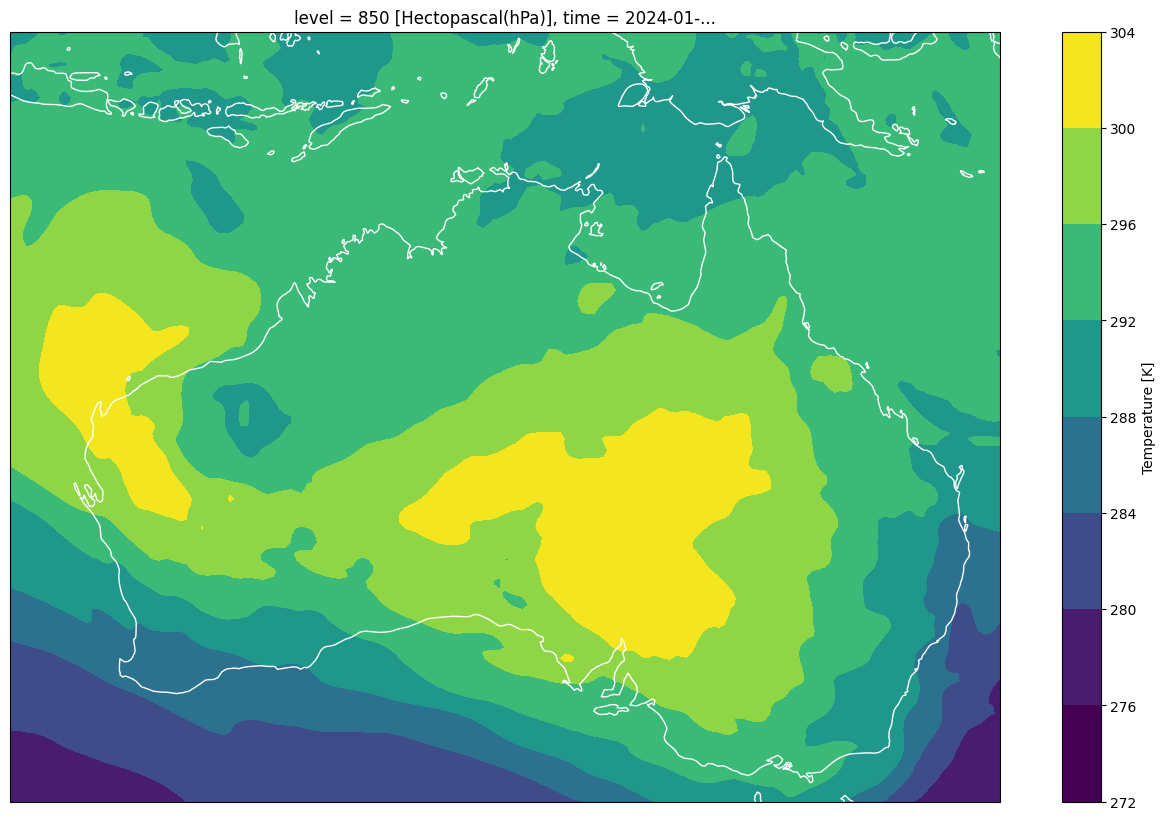

In [11]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
era5_accessor['2024-01-23 17:00']['temperature'].sel(level=850)[0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')